In [ ]:
import keras
from keras.applications.vgg16 import VGG16
model=VGG16()

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [ ]:
model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

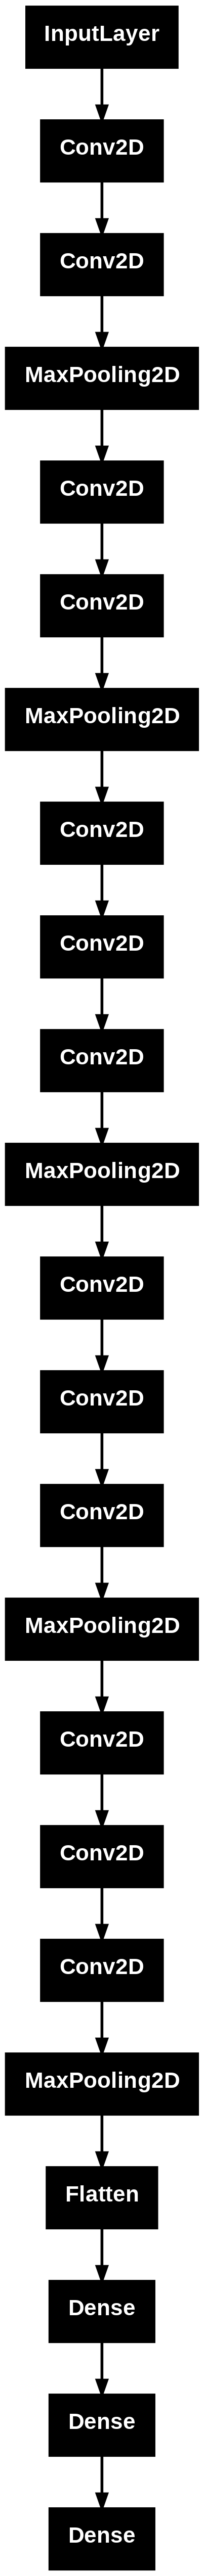

In [ ]:
from keras.utils import plot_model
plot_model(model)

In [ ]:
for i in range(len(model.layers)):
    if "conv"not in model.layers[i].name:
        continue
    filter,bias=model.layers[i].get_weights()
    print(i,model.layers[i].name,filter.shape)

1 block1_conv1 (3, 3, 3, 64)
2 block1_conv2 (3, 3, 64, 64)
4 block2_conv1 (3, 3, 64, 128)
5 block2_conv2 (3, 3, 128, 128)
7 block3_conv1 (3, 3, 128, 256)
8 block3_conv2 (3, 3, 256, 256)
9 block3_conv3 (3, 3, 256, 256)
11 block4_conv1 (3, 3, 256, 512)
12 block4_conv2 (3, 3, 512, 512)
13 block4_conv3 (3, 3, 512, 512)
15 block5_conv1 (3, 3, 512, 512)
16 block5_conv2 (3, 3, 512, 512)
17 block5_conv3 (3, 3, 512, 512)


In [ ]:
filter,bias=model.layers[1].get_weights()

In [ ]:
f_min,f_max=filter.min(),filter.max()
filter=(filter-f_min)/(f_max-f_min)

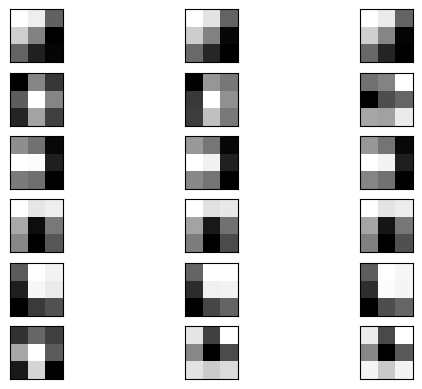

In [ ]:
from matplotlib import pyplot
n_filter, ix = 6, 1
for i in range(n_filter):
    # get the filters
    f = filter[:, :, :, i]
    # plot 3 channels
    for j in range(3):
        # specify subplot and turn of axis
        ax = pyplot.subplot(n_filter, 3, ix)
        ax.set_xticks([])
        ax.set_yticks([])
        # plot filter channel in grayscale
        pyplot.imshow(f[:, :, j], cmap='gray')
        ix += 1
# show the figure
pyplot.show()

# Task
Extract features from an image using a pre-trained VGG16 model.

## Load and preprocess image

### Subtask:
Load an image from a specified directory and preprocess it to the size and format expected by the VGG16 model.


**Reasoning**:
Import necessary libraries and load, preprocess, and reshape the image for VGG16 input.



In [ ]:
from keras.utils import load_img, img_to_array
from keras.applications.vgg16 import preprocess_input
import numpy as np

# Define the path to your image file
image_path = '/content/model.png'  # Replace with your actual image path

# Load the image, specifying the target size
image = load_img(image_path, target_size=(224, 224))

# Convert the image to a NumPy array
image = img_to_array(image)

# Reshape the image data to add the batch size dimension
image = image.reshape((1, image.shape[0], image.shape[1], image.shape[2]))

# Preprocess the image data for VGG16
image = preprocess_input(image)

print("Image loaded and preprocessed successfully.")

Image loaded and preprocessed successfully.


## Define a new model

### Subtask:
Create a new Keras model that includes the VGG16 layers up to the desired convolutional layer for feature extraction.


**Reasoning**:
Create a new sequential model and add layers from the pre-trained VGG16 model up to the desired convolutional layer.



In [ ]:
from keras.models import Sequential

feature_extractor_model = Sequential()

# Iterate through the layers of the pre-trained VGG16 model
for layer in model.layers:
    feature_extractor_model.add(layer)
    # Stop after adding the first convolutional layer (block1_conv1)
    if "conv" in layer.name and "block1_conv1" in layer.name:
        break

feature_extractor_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,792 (7.00 KB)

 Trainable params: 1,792 (7.00 KB)

 Non-trainable params: 0 (0.00 B)

## Extract features

### Subtask:
Apply the new model to the preprocessed image to extract features from the chosen layer.


**Reasoning**:
Apply the feature extractor model to the preprocessed image to get the features and then print the shape of the resulting features.



In [ ]:
# Use the predict method to extract features
features = feature_extractor_model.predict(image)

# Print the shape of the extracted features
print("Shape of extracted features:", features.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step
Shape of extracted features: (1, 224, 224, 64)


## Visualize or use features

### Subtask:
Visualize the extracted features to gain insights into the learned patterns at the chosen convolutional layer.


**Reasoning**:
Visualize the extracted features by plotting them as images.



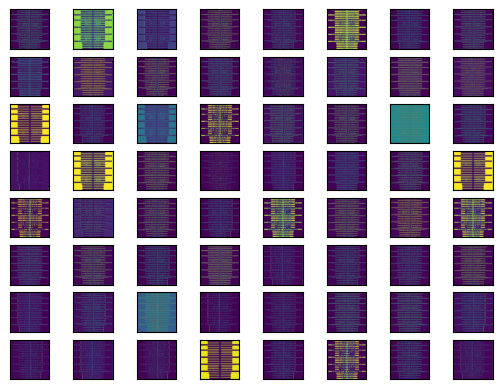

In [ ]:
# Import the matplotlib.pyplot module
from matplotlib import pyplot

# Define the number of features to visualize
n_features_to_visualize = 64

# Create a loop to iterate through the first n_features_to_visualize feature maps
for i in range(n_features_to_visualize):
    # Specify subplot and turn off axis
    ax = pyplot.subplot(8, 8, i + 1)
    ax.set_xticks([])
    ax.set_yticks([])
    # Plot filter channel in grayscale
    pyplot.imshow(features[0, :, :, i], cmap='viridis')

# Show the figure
pyplot.show()

## Summary:

### Data Analysis Key Findings

*   An image was successfully loaded and preprocessed to the required 224x224 pixel size for the VGG16 model.
*   A new Keras sequential model was created, containing the initial convolutional layer (`block1_conv1`) from the pre-trained VGG16 model.
*   Features were extracted from the preprocessed image using the newly created `feature_extractor_model`, resulting in a feature shape of (1, 224, 224, 64).
*   The 64 extracted feature maps from the `block1_conv1` layer were successfully visualized, showcasing the patterns detected by this layer.

### Insights or Next Steps

*   The visualization of the first convolutional layer's feature maps provides insights into the basic patterns (like edges and simple textures) that the VGG16 model learns at an early stage.
*   To understand the hierarchical nature of learned features, the next step could involve extracting and visualizing features from deeper convolutional layers of the VGG16 model.
